In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.data import get_sql_data
from src.cleaning import clean_data
from src.feature_transformation import Transformer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
SEED = 123

Fetching and cleaning the data

In [3]:
df = get_sql_data()
df_clean = clean_data(df)

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
X = df_clean.drop(['bad_score', 'review_score'], axis=1)
y = df_clean['bad_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=SEED)

### Step 1 - Featre transformation
Transforming the data using a custom Transformer class

In [6]:
tr = Transformer()

X_train_tr = tr.fit_transform(X_train, y_train)
X_test_tr = tr.transform(X_test)

In [7]:
X_train_tr.head()

,num_items,freight_ratio,name_len,desc_len,category,prod_photos,weight_g,volume_l,has_missing_details,delivery_days,estimated_delivery_diff,seller_disp_diff,processing_days,is_seller_late,is_delivery_late,log_total_price,log_total_freight
35409,1,0.1320,46,629,0.220639,1,400,2.30,0,13.0,-10.0,-1.0,1,0,0,4.787492,2.816007
8250,1,1.2242,45,176,0.202373,2,200,2.05,0,29.0,-3.0,-5.0,0,0,0,2.889816,3.081910
41230,1,0.2062,35,1054,0.223901,1,350,18.00,0,15.0,-12.0,-1.0,4,0,0,4.510860,2.973487
24415,1,0.1190,52,1015,0.172753,5,1950,13.50,0,4.0,-18.0,-5.0,0,0,0,4.615022,2.557227
14428,1,0.1036,53,3189,0.186811,7,3775,31.50,0,3.0,-15.0,-2.0,2,0,0,4.709440,2.516890


### Step 2 - Feature Elimination

In [122]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.feature_selection import  RFECV, RFE
from sklearn.model_selection import StratifiedKFold

Initializing dummy classifiers with base params to perform further feature importance insepction

In [10]:
scale_weight = (y_train==0).sum() / (y_train==1).sum()

rf = RandomForestClassifier(n_estimators=100, max_depth=5, n_jobs=-1, random_state=123, class_weight='balanced')
xgb = XGBClassifier(scale_pos_weight=scale_weight, n_jobs=-1, random_state=SEED)

In [ ]:
rf.fit(X_train_tr, y_train)
xgb.fit(X_train_tr, y_train)

In [91]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X_train_tr.columns).sort_values()
importances_rf = pd.Series(rf.feature_importances_, index=X_train_tr.columns).sort_values()

Inspecting feature importances of both classifiers to confirm observations from EDA

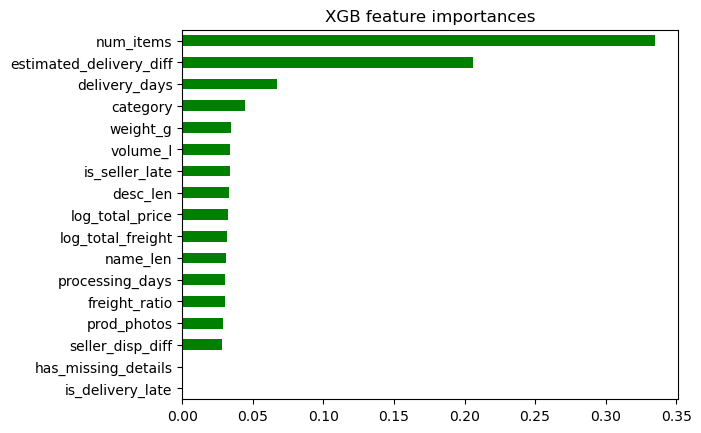

In [115]:
importances_xgb.plot(kind='barh', color='green')
plt.title('XGB feature importances')
plt.show()

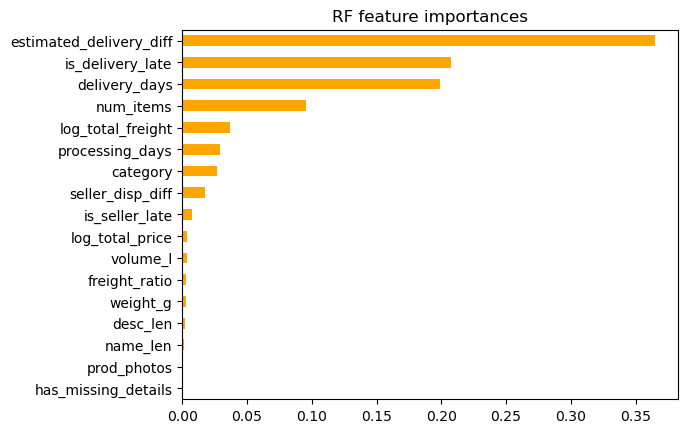

In [ ]:
importances_rf.plot(kind='barh', color='orange')
plt.title('RF feature importances')
plt.grid()
plt.show()

Performing Recursive Feature Elimination with Cross Validation - using Stratified KFold due to imbalanced classes. XGB Classifier has been chosen as an estimator

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

xgb_rfe = XGBClassifier(scale_pos_weight=scale_weight, n_jobs=-1, random_state=SEED)
rfecv = RFECV(estimator=xgb_rfe, step=1, cv=cv, scoring='f1', n_jobs=-1, verbose=1)

In [17]:
rfecv.fit(X_train_tr, y_train)
features_to_keep = X_train_tr.columns[rfecv.support_]

Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.


In [125]:
print('Features to keep: ', list(features_to_keep))
print('RFE results: ', rfecv.cv_results_['mean_test_score'])

Features to keep:  ['num_items', 'desc_len', 'category', 'volume_l', 'delivery_days', 'estimated_delivery_diff', 'log_total_freight']
RFE results:  [0.37598506 0.43368372 0.44156234 0.44309225 0.44429037 0.44164451
 0.44696747 0.4438073  0.4421909  0.44249409 0.44196557 0.44092481
 0.44389963 0.44024543 0.44138166 0.44138166 0.44138166]


Reducing the set of features

In [33]:
X_train_redudced = X_train_tr[features_to_keep]
X_test_reduced = X_test_tr[features_to_keep]

### Step 3 - Hyperparameter tuning with Optuna

In [20]:
import optuna
from sklearn.metrics import f1_score 

Defining objective functions for both Random Forest and XGB Classifiers. The F1 score is to be maximized

In [25]:
def objective_xgb(trial: optuna.trial.Trial):

    scale_weight = (y_train==0).sum() / (y_train==1).sum()

    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 2, 15),
        'gamma': trial.suggest_float('gamma', 0, 5),

        #rest of the parameters
        'scale_pos_weight': scale_weight,
        'tree_method': 'hist',
        'device': 'cuda',
        
        'random_state': SEED
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []

    for train_idx, validation_idx in cv.split(X_train_redudced, y_train):
        X_tr, X_val = X_train_redudced.iloc[train_idx], X_train_redudced.iloc[validation_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[validation_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)

        scores.append(score)

    return np.mean(scores)

In [24]:
def objective_rf(trial: optuna.trial.Trial):

    params = {
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_float('max_features', 0.4, 0.8),

        #rest of the parameters
        'class_weight': 'balanced',
        'n_jobs': -1,
        
        'random_state': SEED
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = []

    for train_idx, validation_idx in cv.split(X_train_redudced, y_train):
        X_tr, X_val = X_train_redudced.iloc[train_idx], X_train_redudced.iloc[validation_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[validation_idx]

        model = RandomForestClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)

        scores.append(score)

    return np.mean(scores)

In [26]:
study_xgb = optuna.create_study(study_name='XGB_study', direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True, n_jobs=-1)

[I 2026-02-21 20:58:20,044] A new study created in memory with name: XGB_study


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-21 20:58:48,869] Trial 15 finished with value: 0.4545162181664776 and parameters: {'max_depth': 3, 'learning_rate': 0.09889815529142419, 'n_estimators': 364, 'subsample': 0.7151970785523819, 'colsample_bytree': 0.9943114843149866, 'min_child_weight': 2, 'gamma': 0.777730692573752}. Best is trial 15 with value: 0.4545162181664776.
[I 2026-02-21 20:58:54,031] Trial 6 finished with value: 0.45686407581677846 and parameters: {'max_depth': 5, 'learning_rate': 0.05567930335596198, 'n_estimators': 580, 'subsample': 0.9535512344474883, 'colsample_bytree': 0.764539747217664, 'min_child_weight': 7, 'gamma': 4.016221789571058}. Best is trial 6 with value: 0.45686407581677846.
[I 2026-02-21 20:58:56,246] Trial 11 finished with value: 0.45743328308251013 and parameters: {'max_depth': 3, 'learning_rate': 0.010764727198110032, 'n_estimators': 457, 'subsample': 0.9102527155870404, 'colsample_bytree': 0.9432190617597326, 'min_child_weight': 11, 'gamma': 2.4453624379206493}. Best is trial 11 

Inspecting best XGB parameters and F1 score

In [29]:
print('Best params: ', study_xgb.best_params)
print('Best F1 score:', study_xgb.best_value)

Best params:  {'max_depth': 4, 'learning_rate': 0.011085995609080995, 'n_estimators': 422, 'subsample': 0.8159950297561769, 'colsample_bytree': 0.9123778780298678, 'min_child_weight': 8, 'gamma': 0.6617576480211471}
Best F1 score: 0.45949060700250977


In [30]:
study_rf = optuna.create_study(study_name='RF_study', direction='maximize')
study_rf.optimize(objective_rf, n_trials=70, show_progress_bar=True, n_jobs=-1)

[I 2026-02-21 21:04:24,237] A new study created in memory with name: RF_study


  0%|          | 0/70 [00:00<?, ?it/s]

[I 2026-02-21 21:05:43,698] Trial 2 finished with value: 0.4545775113498608 and parameters: {'max_depth': 10, 'n_estimators': 106, 'min_samples_split': 17, 'min_samples_leaf': 1, 'max_features': 0.6748567344151206}. Best is trial 2 with value: 0.4545775113498608.
[I 2026-02-21 21:05:52,831] Trial 5 finished with value: 0.4571464609522787 and parameters: {'max_depth': 7, 'n_estimators': 139, 'min_samples_split': 19, 'min_samples_leaf': 14, 'max_features': 0.4135481551020461}. Best is trial 5 with value: 0.4571464609522787.
[I 2026-02-21 21:05:53,265] Trial 12 finished with value: 0.45641063247892466 and parameters: {'max_depth': 6, 'n_estimators': 141, 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 0.47897014989702413}. Best is trial 5 with value: 0.4571464609522787.
[I 2026-02-21 21:06:02,382] Trial 13 finished with value: 0.45558758229330476 and parameters: {'max_depth': 6, 'n_estimators': 162, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 0.6006258

Inspecting best RF parameters and F1 score

In [31]:
print('Best params: ', study_rf.best_params)
print('Best F1 score:', study_rf.best_value)

Best params:  {'max_depth': 9, 'n_estimators': 493, 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 0.40197522542096353}
Best F1 score: 0.4589271391802744


In [40]:
final_params_xgb = study_xgb.best_params.copy()
final_params_xgb['scale_pos_weight'] =  scale_weight
final_params_xgb['random_state'] = SEED
final_params_xgb['n_jobs'] = -1

final_params_rf = study_rf.best_params.copy()
final_params_rf['class_weight'] = 'balanced'
final_params_rf['random_state'] = SEED
final_params_rf['n_jobs'] = -1


In [42]:
best_xgb = XGBClassifier(**final_params_xgb)
best_rf = RandomForestClassifier(**final_params_rf)

best_xgb.fit(X_train_redudced, y_train)
best_rf.fit(X_train_redudced, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9,
                       max_features=0.40197522542096353, min_samples_leaf=15,
                       min_samples_split=20, n_estimators=493, n_jobs=-1,
                       random_state=123)

In [123]:
from sklearn.metrics import classification_report

### Step 4 - Reviewing both models performance on the test set - their F1 scores are almost identical

In [121]:
y_pred_xgb = best_xgb.predict(X_test_reduced)
xgb_report = classification_report(y_test, y_pred_xgb)
print(xgb_report)
print(f'XGB F1 score: {f1_score(y_test, y_pred_xgb):.4f}')

              precision    recall  f1-score   support

           0       0.86      0.81      0.83     15128
           1       0.41      0.50      0.45      4034

    accuracy                           0.75     19162
   macro avg       0.64      0.66      0.64     19162
weighted avg       0.77      0.75      0.75     19162

XGB F1 score: 0.4531


In [119]:
y_pred_rf = best_rf.predict(X_test_reduced)
rf_report = classification_report(y_test, y_pred_rf)
print(rf_report)
print(f'RF F1 score: {f1_score(y_test, y_pred_rf):.4f}')

              precision    recall  f1-score   support

           0       0.86      0.83      0.84     15128
           1       0.43      0.48      0.45      4034

    accuracy                           0.76     19162
   macro avg       0.64      0.65      0.65     19162
weighted avg       0.77      0.76      0.76     19162

RF F1 score: 0.4532


Dumping the best models into the pkl files for further usage

In [78]:
import joblib
xgb_path = os.path.join('..','models', 'best_xgb.pkl')
rf_path = os.path.join('..','models', 'best_rf.pkl')

In [79]:
joblib.dump(best_xgb, xgb_path)
joblib.dump(best_rf, rf_path)

['..\\models\\best_rf.pkl']